# 📚 第 73 课 · CANN 软件栈:从应用接口到芯片执行的五层结构

> ACL · 图引擎 GE · 算子层 · Runtime · 驱动 —— 与 CUDA 逐层对照,看懂昇腾的『软件中枢』

**章节**: 第 11 章 · 华为昇腾与 MindSpore 生态

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 CANN 的定位:框架与昇腾芯片之间的『硬件使能层』
- 掌握五层结构:ACL 应用层 / 图引擎 GE / 算子层 / Runtime / 驱动 + HCCL
- 看懂 ACL 推理接口的标准流程(Init → 加载模型 → 执行 → 清理)
- 理解 GE 整图下沉:为什么『一次编译整图』比逐算子启动更快
- 逐层对照 CANN 与 CUDA 栈,建立『思想同源、实现各异』的认知
- 跑通配套 App:交互浏览软件栈各层

## 📑 本课目录

1. **直觉:一部手机组装厂** — 五个部门层层递进,最后把『图纸』变成『手机』
2. **五层结构逐一看** — ACL / GE / 算子层 / Runtime / 驱动的分工表格
3. **ACL 推理流程** — 伪代码 + 可运行的 Python 流程模拟
4. **GE 整图下沉** — 为什么整图编译一次,胜过逐算子启动 N 次
5. **CANN vs CUDA 对照表** — 两个软件栈逐层 PK,双栈并排结构图
6. **配套 Streamlit 演示** — app_73_cann_stack.py:层次交互浏览

## 🔗 参考资料

- [昇腾 CANN 文档中心](https://www.hiascend.com/document)
- [昇腾社区官网](https://www.hiascend.com)
- [MindSpore 官方文档](https://www.mindspore.cn)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 OMP 库冲突(Windows)
import time, math
import numpy as np
import pandas as pd
import torch

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
print("本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。")

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


本机未安装 MindSpore / 无昇腾硬件:全章用 torch + matplotlib 类比讲解真实概念。


## 1️⃣ 直觉:一部手机组装厂 📱

想象一座手机组装厂,要把"设计图纸"(神经网络模型)变成"能用的手机"(在昇腾上跑起来),
需要五个部门层层接力:

1. **ACL 应用开发层**(接待前台):对外提供标准接口 —— 你说"我要跑这个模型",它负责
   安排设备、加载模型、把结果交给你;
2. **图引擎 GE**(总装调度):拿到图纸后先优化 —— 能合并的工序合并、能省的材料省掉,
   然后**一次性排好整个产线(整图下沉)**;
3. **算子层**(零件车间):提供现成的"零件"(conv、relu、softmax……),也允许你
   用 **Ascend C** 自己开模具(自研算子);
4. **运行时 Runtime**(流水线电控):管理产线的电闸与传送带 —— 任务调度、内存分配、
   流(Stream)管理;
5. **驱动 + HCCL**(电机与物流):驱动让传送带真正转起来,HCCL 让多间厂房(多卡)之间
   能快速运货(集合通信)。

这套五层结构就是 **CANN**。它夹在框架与芯片之间,让 PyTorch、MindSpore 这些"设计院"
不用关心芯片怎么造 —— 这就是『使能』二字的意思。

## 2️⃣ 五层结构逐一看 🧱

用一张表把五层的职责、输入输出、对标组件讲清楚:

| 层次 | 职责 | 输入 → 输出 | 类比 CUDA 生态 |
|------|------|------------|---------------|
| **ACL 应用开发层** | 应用接口:设备/模型/推理 | 模型+数据 → 结果 | CUDA Runtime 之上的应用 API |
| **图引擎 GE** | 图优化、算子融合、整图下沉 | 计算图 → 可执行图 | CUDA Graph 捕获 |
| **算子层** | 内置算子库 + Ascend C 开发 | 算子定义 → 算子实现 | cuDNN/cuBLAS + CUDA kernel |
| **运行时 Runtime** | 调度、内存、Stream | 任务 → 执行 | CUDA Runtime / Driver |
| **驱动 + HCCL** | 芯片对接 + 多卡通信 | 指令 → 执行 + 协同 | 驱动 + NCCL |

注意:**昇腾比 CUDA 更强调『图』**。NVIDIA 是"逐 kernel 启动",昇腾 CANN 是"先整图编译、
再整体下沉" —— 这一差异贯穿后面几课。

## 3️⃣ ACL 推理流程:一条固定的『接线图』 🔌

ACL(昇腾计算语言)是应用开发者的第一站。推理一段模型的流程是**固定的九步**,
像个接线图 —— 先初始化、再指定设备、加载模型、拷入输入、执行、拷回输出、最后清理。
真实 ACL 是 C/Python API,这里用 Python 把它"翻译"成可运行的模拟流程(本机无昇腾,
只看流程骨架):

🎯 注意:ACL 流程的关键词是『顺序固定、资源显式管理』—— 没有自动内存管理,每一步都要自己申请与释放,这是 C 系 API 的常见风格。

In [2]:
def acl_inference_pipeline(model_path, input_data):
    steps = [
        ("aclInit", "初始化 ACL 环境", ""),
        ("aclrtSetDevice", "指定设备(如 0 号昇腾卡)", "device=0"),
        ("aclrtCreateContext", "创建上下文", "ctx"),
        ("aclmdlLoadFromFile", "从文件加载离线模型", f"model_id = {model_path}"),
        ("aclmdlCreateDataset", "创建输入/输出数据集", "dataset"),
        ("aclrtMemcpy", "Host → Device 拷入输入数据", f"{len(input_data)} 个元素"),
        ("aclmdlExecute", "执行模型推理", "output"),
        ("aclrtMemcpy", "Device → Host 拷回输出", "output[]"),
        ("aclFinalize", "卸载模型并销毁资源", ""),
    ]
    print(f"{'步骤':<22}{'作用':<32}{'备注'}")
    print("-" * 74)
    for api, desc, note in steps:
        print(f"{api:<22}{desc:<32}{note}")
    print("\n流程完成,得到推理输出:", "OK")
    return "output"

_ = acl_inference_pipeline("resnet50.om", [0.1] * 224)

步骤                    作用                              备注
--------------------------------------------------------------------------
aclInit               初始化 ACL 环境                      
aclrtSetDevice        指定设备(如 0 号昇腾卡)                  device=0
aclrtCreateContext    创建上下文                           ctx
aclmdlLoadFromFile    从文件加载离线模型                       model_id = resnet50.om
aclmdlCreateDataset   创建输入/输出数据集                      dataset
aclrtMemcpy           Host → Device 拷入输入数据            224 个元素
aclmdlExecute         执行模型推理                          output
aclrtMemcpy           Device → Host 拷回输出              output[]
aclFinalize           卸载模型并销毁资源                       

流程完成,得到推理输出: OK


## 4️⃣ GE 整图下沉:一次编译,胜过逐算子启动 N 次 🏗️

**GE(图引擎)** 是 CANN 里最"编译器"的一层:模型加载时,它拿到整张计算图,做
**算子融合、内存规划、常量折叠**……最后把整张图**一次性编译成可执行任务,整体下沉
(offload)到昇腾芯片上**。从此芯片按图上的依赖关系自己调度,不再需要 Host 逐算子干预。

这和 **CUDA Graph** 是同一个思想:把 N 次"启动 kernel + 等待"的往返,压成一次。
算一笔账 —— 假设一张图有 30 个算子,每个算子启动要 5 μs,逐算子跑 100 轮 vs
整图编译一次再跑:

📊 账本:逐算子启动的往返开销随『算子数 × 轮数』线性累积;整图下沉把编译成本摊薄在长期运行里 —— 轮数越多越划算。

逐算子启动: 30 算子 × 5μs × 100 轮 = 15.0 ms
整图下沉:   编译 30ms + 5μs × 100 轮 = 30.5 ms
节省:        -103% 的启动开销


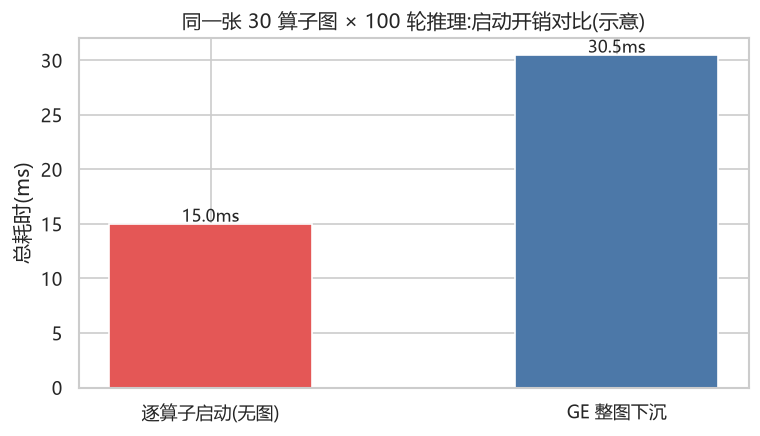

In [3]:
ops = 30                     # 图中算子个数
launch_us = 5                # 单算子启动开销(示意, μs)
compile_cost_ms = 30         # 整图编译一次的开销(示意, ms)
iters = 100
t_eager_ms = ops * launch_us * iters / 1000              # 逐算子 × 100 轮
t_graph_ms = compile_cost_ms + launch_us * iters / 1000  # 编译一次 + 每轮一次启动
print(f"逐算子启动: {ops} 算子 × {launch_us}μs × {iters} 轮 = {t_eager_ms:.1f} ms")
print(f"整图下沉:   编译 {compile_cost_ms}ms + {launch_us}μs × {iters} 轮 = {t_graph_ms:.1f} ms")
print(f"节省:        {(t_eager_ms - t_graph_ms) / t_eager_ms * 100:.0f}% 的启动开销")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
bars = ax.bar(["逐算子启动(无图)", "GE 整图下沉"], [t_eager_ms, t_graph_ms],
              color=["#E45756", "#4C78A8"], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2, f"{b.get_height():.1f}ms",
            ha="center", fontsize=10)
ax.set_ylabel("总耗时(ms)")
ax.set_title(f"同一张 {ops} 算子图 × {iters} 轮推理:启动开销对比(示意)")
plt.tight_layout()

## 5️⃣ CANN vs CUDA:双栈对照图 ⚖️

把两个软件栈并排画出来,一眼看懂"思想同源、实现各异":CUDA 偏『逐 kernel』,
昇腾偏『整图』;但每一层都能对上号。

🎨 双栈图:CANN 与 CUDA 逐层对应 —— 差异核心在『GE 整图下沉 vs 逐 kernel 启动』。

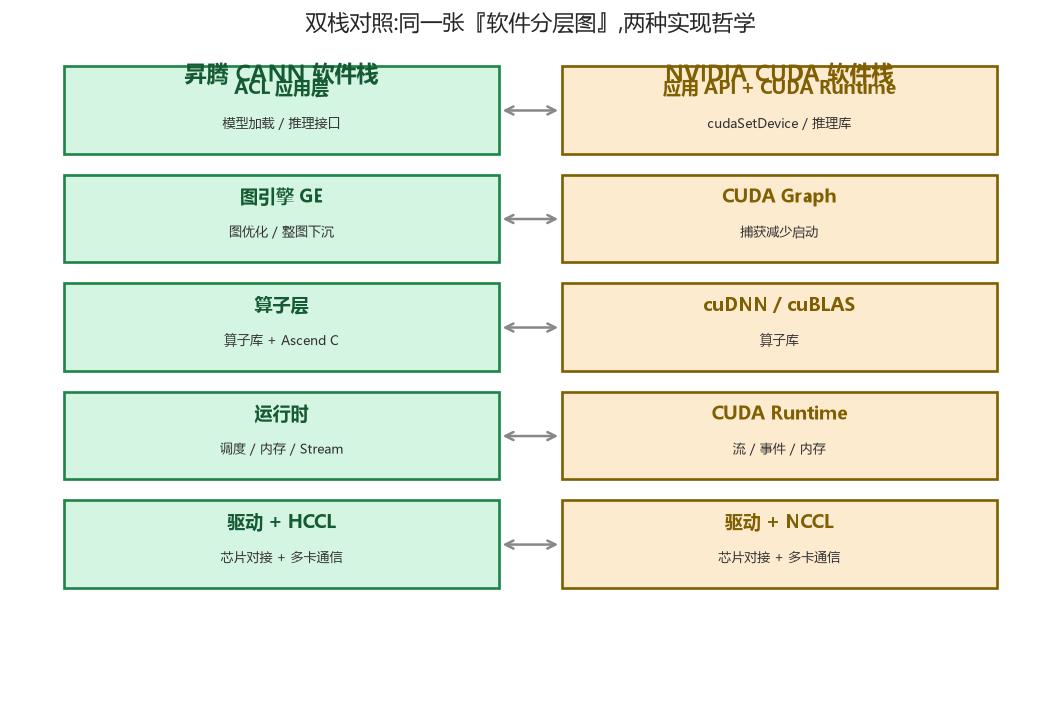

In [4]:
fig, ax = plt.subplots(figsize=(9, 6.2))
ax.axis("off")
cann = [
    ("ACL 应用层", "模型加载 / 推理接口", "#d5f5e3"),
    ("图引擎 GE", "图优化 / 整图下沉", "#d5f5e3"),
    ("算子层", "算子库 + Ascend C", "#d5f5e3"),
    ("运行时", "调度 / 内存 / Stream", "#d5f5e3"),
    ("驱动 + HCCL", "芯片对接 + 多卡通信", "#d5f5e3"),
]
cuda = [
    ("应用 API + CUDA Runtime", "cudaSetDevice / 推理库", "#fdebd0"),
    ("CUDA Graph", "捕获减少启动", "#fdebd0"),
    ("cuDNN / cuBLAS", "算子库", "#fdebd0"),
    ("CUDA Runtime", "流 / 事件 / 内存", "#fdebd0"),
    ("驱动 + NCCL", "芯片对接 + 多卡通信", "#fdebd0"),
]
y = 5.2
for (t1, s1, c1), (t2, s2, c2) in zip(cann, cuda):
    ax.add_patch(plt.Rectangle((0.5, y), 4.2, 0.85, facecolor=c1, edgecolor="#1e8449", lw=1.6))
    ax.text(2.6, y + 0.58, t1, ha="center", fontsize=11, fontweight="bold", color="#145a32")
    ax.text(2.6, y + 0.25, s1, ha="center", fontsize=8, color="#333")
    ax.add_patch(plt.Rectangle((5.3, y), 4.2, 0.85, facecolor=c2, edgecolor="#7f5f01", lw=1.6))
    ax.text(7.4, y + 0.58, t2, ha="center", fontsize=11, fontweight="bold", color="#7f5f01")
    ax.text(7.4, y + 0.25, s2, ha="center", fontsize=8, color="#333")
    ax.annotate("", xy=(5.3, y + 0.42), xytext=(4.7, y + 0.42),
                arrowprops=dict(arrowstyle="<->", lw=1.5, color="#888"))
    y -= 1.05
ax.text(2.6, 5.9, "昇腾 CANN 软件栈", ha="center", fontsize=13, fontweight="bold", color="#145a32")
ax.text(7.4, 5.9, "NVIDIA CUDA 软件栈", ha="center", fontsize=13, fontweight="bold", color="#7f5f01")
ax.set_xlim(0, 10); ax.set_ylim(-0.2, 6.3)
ax.set_title("双栈对照:同一张『软件分层图』,两种实现哲学", fontsize=13)
plt.tight_layout()

## 6️⃣ 配套 Streamlit 演示:软件栈层次交互浏览 🎛️

运行同目录下的 `app_73_cann_stack.py`,可以**选择软件栈某一层**查看它的职责、输入输出、
对应用例与 CUDA 类比,还能展开作用评分图与双栈对照表:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_73_cann_stack.py
```

浏览器打开 **http://localhost:8501**。建议在『ACL 应用层』与『图引擎 GE』之间来回切换,
体会"开发者日常接触层"与"性能关键层"的差异。完整源码如下(与同目录
`app_73_cann_stack.py` 一字不差):

📜 运行本 cell 会覆盖写入 `app_73_cann_stack.py`,保证 notebook 与 app 始终一致。

In [5]:
%%writefile app_73_cann_stack.py
# -*- coding: utf-8 -*-
# app_73_cann_stack.py — CANN 软件栈层次交互浏览 📚
import streamlit as st
import plotly.graph_objects as go
import pandas as pd

st.set_page_config(page_title="CANN 软件栈 📚", layout="wide")
st.title("📚 第 73 课 · CANN 软件栈:层次交互浏览")

st.markdown("""
CANN(昇腾异构计算架构)是昇腾的**软件中枢**,把上层框架(PyTorch / MindSpore)翻译成
昇腾芯片能执行的任务。它分成好几层,每层各司其职。下方**选择一层**,看它的职责、
输入输出与对应用例;再打开对照表,与 CUDA 软件栈逐层对照。
""")

LAYERS = {
    "ACL 应用开发层(昇腾计算语言)": {
        "职责": "面向应用/推理场景的 C/Python API:设备管理、模型加载、推理执行",
        "输入": "离线模型 + 输入数据", "输出": "推理结果",
        "对应用例": "aclInit → aclrtSetDevice → aclmdlLoadFromFile → aclmdlExecute",
        "类比 CUDA": "应用 API + cudaSetDevice / cudaMemcpy",
        "作用": 5,
    },
    "图引擎 GE": {
        "职责": "把计算图做优化与编译:算子融合、内存规划、整图下沉到设备",
        "输入": "框架计算图(MindIR / ONNX 等)", "输出": "可执行图 / 融合后算子",
        "对应用例": "GE 在模型加载阶段自动完成图优化与整图下沉",
        "类比 CUDA": "CUDA Graph 捕获(减少 kernel 启动)",
        "作用": 5,
    },
    "算子层(算子库 + Ascend C)": {
        "职责": "预置 NN 算子库 + Ascend C 算子开发语言,可自研高性能算子",
        "输入": "算子的数学定义 + shape 信息", "输出": "可执行算子实现",
        "对应用例": "调用 conv/relu/softmax 等内置算子,或用 Ascend C 写自定义算子",
        "类比 CUDA": "cuDNN / cuBLAS + 手写 CUDA kernel",
        "作用": 4,
    },
    "运行时 Runtime": {
        "职责": "设备管理、内存管理、任务调度与 Stream 流管理",
        "输入": "可执行算子 / 图任务", "输出": "设备上按流调度的执行",
        "对应用例": "aclrtCreateStream / aclrtSynchronizeStream",
        "类比 CUDA": "CUDA Runtime(cudaStream 等)",
        "作用": 4,
    },
    "驱动 + HCCL": {
        "职责": "驱动对接芯片;HCCL 提供多卡集合通信(AllReduce 等)",
        "输入": "执行指令 / 梯度数据", "输出": "芯片执行 + 多卡协同",
        "对应用例": "分布式训练时的 AllReduce 梯度同步",
        "类比 CUDA": "NVIDIA 驱动 + NCCL",
        "作用": 3,
    },
}

with st.sidebar:
    st.header("🎛️ 参数")
    layer = st.selectbox("选择软件栈层次", list(LAYERS.keys()))
    show_bar = st.checkbox("显示各层作用评分图", value=True)
    show_compare = st.checkbox("显示 CANN vs CUDA 对照表", value=True)
    st.caption("CANN 每一层都能在 CUDA 生态里找到影子,但实现与调度方式不同。")

info = LAYERS[layer]
st.subheader(f"🔍 {layer}")
c1, c2 = st.columns(2)
c1.markdown(f"**职责**:{info['职责']}\n\n**输入**:{info['输入']}\n\n**输出**:{info['输出']}")
c2.markdown(f"**对应用例**:`{info['对应用例']}`\n\n**类比 CUDA**:{info['类比 CUDA']}")
st.metric("该层作用(示意 1-5)", info["作用"])

if show_bar:
    st.subheader("📊 各层作用评分(示意)")
    df = pd.DataFrame({"层": list(LAYERS.keys()), "作用": [v["作用"] for v in LAYERS.values()]})
    fig = go.Figure(go.Bar(x=df["作用"], y=df["层"], orientation="h",
                           marker_color="#4C78A8", text=df["作用"], textposition="outside"))
    fig.update_layout(title="CANN 各层次作用评分(示意)", height=380,
                      xaxis_title="作用(1-5)", yaxis_title="", margin=dict(l=10, r=10, t=50, b=10))
    st.plotly_chart(fig, use_container_width=True)
    st.caption("⭐ 提示:ACL 与 GE 是『开发者接触最多』的两层,算子层是性能调优主战场。")

if show_compare:
    st.subheader("📋 CANN vs CUDA 对照表")
    rows = [{"层次": k, "CANN 对应组件": LAYERS[k]["对应用例"],
             "CUDA 类比": LAYERS[k]["类比 CUDA"]} for k in LAYERS]
    st.dataframe(pd.DataFrame(rows), use_container_width=True)
    st.caption("对照是『思想同源、实现各异』:CUDA 是逐 kernel 启动,昇腾更强调整图下沉。")

st.markdown("""
> 💡 **一句话**:CANN 之于昇腾,就像 CUDA 之于 NVIDIA —— 是硬件与框架之间的『总翻译官』。
> 理解 CANN 的层次,就理解了昇腾上所有推理引擎(vLLM / MindIE)的落地路径。
""")

Overwriting app_73_cann_stack.py


## ✅ 本课小结

- CANN 五层:ACL 应用层 / 图引擎 GE / 算子层 / 运行时 Runtime / 驱动 + HCCL
- ACL 推理流程九步固定:Init → SetDevice → 加载 → 拷入 → 执行 → 拷回 → 清理
- GE 整图下沉把『逐算子启动 × N 轮』压成『编译一次 + 每轮一次启动』,轮数越多越省
- CANN 与 CUDA 逐层对应,差异核心:昇腾偏『整图』,NVIDIA 偏『逐 kernel』
- HCCL 对标 NCCL,提供多卡 AllReduce 等集合通信(第 80 课展开)

## ✍️ 动手练习

1. 给 acl_inference_pipeline 增加 aclrtCreateStream / aclrtSynchronizeStream 两步,重跑打印
2. 把 GE 账本里的 iters 从 100 改成 1 和 1000,观察哪种模式下逐算子启动反而更快(少于某轮数)
3. 在双栈对照图里新增一行『多租户/虚拟化』,分别写 CANN 与 CUDA 的对应组件
4. 查 CANN 文档,找 ACL 与 C 语言 API 的命名规律(aclmdl / aclrt / aclfv 前缀),总结分类

## 🔗 延伸阅读

- [昇腾 CANN 文档中心](https://www.hiascend.com/document)
- [昇腾社区官网](https://www.hiascend.com)
- [NVIDIA CUDA 编程指南](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)

---
> 🎉 恭喜完成本课!下一课见!